# Manufacturing Quality Analytics

### End-to-End Data Analysis Project

**Tools:** Excel | MySQL | Python | Power BI

**Objective:** Analyze manufacturing inspection data to identify quality issues, defect patterns, downtime trends, and process performance.

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [106]:
df = pd.read_csv(
    r"C:\Users\Tripti Sahu\Desktop\P\Manufacturing Quality Analytics\data\manufacturing_quality_cleaned.csv"
)

df.shape

(1500, 24)

In [107]:
df = df.drop(columns=["Column1"])

df.shape

(1500, 23)

In [108]:
df.head()

,Inspection_ID,Inspection_Date,Plant,Production_Line,Product,Shift,Machine_ID,Operator_ID,Batch_ID,Production_Qty,...,Cycle_Time_Sec,Temperature_C,Pressure_Bar,Vibration_mm_s,Material_Batch,Supplier,Inspection_Status,Temperature_Flag,Pressure_Flag,Vibration_Flag
0,10063,24-09-2025 00:00,Plant A,Line 4,Widget C,Morning,M-09,OP-103,B1152,1230,...,41.5,160.0,5.30,3.05,MB-233,Supplier W,Pass,Investigate,Normal,Normal
1,10611,08-07-2025 00:00,Plant A,Line 2,Widget B,Night,M-06,OP-124,B1175,621,...,41.6,145.0,5.68,3.97,MB-241,Supplier Z,Review,Investigate,Normal,Normal
2,11147,18-01-2025 00:00,Plant B,Line 3,Widget B,Evening,M-10,OP-112,B1103,1236,...,50.6,95.6,4.53,0.13,MB-237,Supplier Z,Review,Normal,Normal,Normal
3,10127,31-10-2025 00:00,Plant A,Line 3,Widget D,Morning,M-09,OP-109,B1067,717,...,46.6,93.5,3.75,2.04,MB-211,Supplier Y,Pass,Normal,Normal,Normal
4,10882,01-06-2025 00:00,Plant A,Line 2,Widget C,Morning,M-11,OP-108,B1196,1332,...,44.6,92.3,5.27,2.51,MB-219,Supplier W,Pass,Normal,Normal,Normal


In [109]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Inspection_ID      1500 non-null   int64  
 1   Inspection_Date    1500 non-null   str    
 2   Plant              1500 non-null   str    
 3   Production_Line    1500 non-null   str    
 4   Product            1500 non-null   str    
 5   Shift              1500 non-null   str    
 6   Machine_ID         1500 non-null   str    
 7   Operator_ID        1500 non-null   str    
 8   Batch_ID           1500 non-null   str    
 9   Production_Qty     1500 non-null   int64  
 10  Defect_Qty         1500 non-null   int64  
 11  Defect_Type        1500 non-null   str    
 12  Downtime_Min       1500 non-null   int64  
 13  Cycle_Time_Sec     1500 non-null   float64
 14  Temperature_C      1500 non-null   float64
 15  Pressure_Bar       1500 non-null   float64
 16  Vibration_mm_s     1500 non-null   

In [110]:
df["Inspection_Date"] = pd.to_datetime(
    df["Inspection_Date"],
    format="%d-%m-%Y %H:%M"
)

df["Inspection_Date"].dtype

dtype('<M8[us]')

In [111]:
df.isnull().sum()

Inspection_ID        0
Inspection_Date      0
Plant                0
Production_Line      0
Product              0
Shift                0
Machine_ID           0
Operator_ID          0
Batch_ID             0
Production_Qty       0
Defect_Qty           0
Defect_Type          0
Downtime_Min         0
Cycle_Time_Sec       0
Temperature_C        0
Pressure_Bar         0
Vibration_mm_s       0
Material_Batch       0
Supplier             0
Inspection_Status    0
Temperature_Flag     0
Pressure_Flag        0
Vibration_Flag       0
dtype: int64

In [112]:
df.duplicated().sum()

np.int64(0)

In [113]:
df.describe()

,Inspection_ID,Inspection_Date,Production_Qty,Defect_Qty,Downtime_Min,Cycle_Time_Sec,Temperature_C,Pressure_Bar,Vibration_mm_s
count,1500.000000,1500,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,10750.500000,2025-06-29 11:52:19.200000,1010.124000,17.395333,91.560667,42.011733,71.636867,5.216047,2.796193
min,10001.000000,2025-01-01 00:00:00,450.000000,1.000000,5.000000,13.500000,12.000000,0.400000,0.010000
25%,10375.750000,2025-03-28 00:00:00,725.000000,6.000000,45.000000,37.300000,66.200000,4.670000,1.980000
50%,10750.500000,2025-06-27 00:00:00,1011.500000,11.000000,91.000000,41.900000,71.500000,5.200000,2.780000
75%,11125.250000,2025-10-05 00:00:00,1296.000000,20.000000,136.000000,46.600000,76.700000,5.732500,3.520000
max,11500.000000,2025-12-31 00:00:00,1599.000000,155.000000,180.000000,66.600000,160.000000,18.000000,18.000000
std,433.157015,NaN,329.371537,19.295161,51.396025,6.843885,8.357471,0.874024,1.250566


In [114]:
total_inspections = df["Inspection_ID"].nunique()
total_production = df["Production_Qty"].sum()
total_defects = df["Defect_Qty"].sum()
total_downtime = df["Downtime_Min"].sum()

defect_rate = (total_defects / total_production) * 100
quality_rate = (1 - total_defects / total_production) * 100

avg_cycle_time = df["Cycle_Time_Sec"].mean()
avg_temperature = df["Temperature_C"].mean()
avg_pressure = df["Pressure_Bar"].mean()
avg_vibration = df["Vibration_mm_s"].mean()

print("Total Inspections:", total_inspections)
print("Total Production:", total_production)
print("Total Defects:", total_defects)
print("Defect Rate:", round(defect_rate, 2), "%")
print("Quality Rate:", round(quality_rate, 2), "%")
print("Total Downtime:", total_downtime, "minutes")
print("Average Cycle Time:", round(avg_cycle_time, 2), "sec")
print("Average Temperature:", round(avg_temperature, 2), "°C")
print("Average Pressure:", round(avg_pressure, 2), "bar")
print("Average Vibration:", round(avg_vibration, 2), "mm/s")

Total Inspections: 1500
Total Production: 1515186
Total Defects: 26093
Defect Rate: 1.72 %
Quality Rate: 98.28 %
Total Downtime: 137341 minutes
Average Cycle Time: 42.01 sec
Average Temperature: 71.64 °C
Average Pressure: 5.22 bar
Average Vibration: 2.8 mm/s


In [115]:
plant_analysis = df.groupby("Plant").agg(
    Inspections=("Inspection_ID", "count"),
    Production=("Production_Qty", "sum"),
    Defects=("Defect_Qty", "sum"),
    Downtime=("Downtime_Min", "sum")
).reset_index()

plant_analysis["Defect_Rate"] = (
    plant_analysis["Defects"] / plant_analysis["Production"] * 100
).round(2)

plant_analysis

,Plant,Inspections,Production,Defects,Downtime,Defect_Rate
0,Plant A,496,504464,9480,47099,1.88
1,Plant B,501,506129,8382,43833,1.66
2,Plant C,503,504593,8231,46409,1.63


In [116]:
line_analysis = df.groupby("Production_Line").agg(
    Inspections=("Inspection_ID", "count"),
    Production=("Production_Qty", "sum"),
    Defects=("Defect_Qty", "sum"),
    Downtime=("Downtime_Min", "sum")
).reset_index()

line_analysis["Defect_Rate"] = (
    line_analysis["Defects"] / line_analysis["Production"] * 100
).round(2)

line_analysis

,Production_Line,Inspections,Production,Defects,Downtime,Defect_Rate
0,Line 1,375,379228,6735,33148,1.78
1,Line 2,354,361934,6203,33204,1.71
2,Line 3,411,410934,7169,38532,1.74
3,Line 4,360,363090,5986,32457,1.65


In [117]:
product_analysis = df.groupby("Product").agg(
    Inspections=("Inspection_ID", "count"),
    Production=("Production_Qty", "sum"),
    Defects=("Defect_Qty", "sum"),
    Downtime=("Downtime_Min", "sum")
).reset_index()

product_analysis["Defect_Rate"] = (
    product_analysis["Defects"] / product_analysis["Production"] * 100
).round(2)

product_analysis

,Product,Inspections,Production,Defects,Downtime,Defect_Rate
0,Widget A,380,388880,6887,35835,1.77
1,Widget B,343,339990,5344,31389,1.57
2,Widget C,404,415524,7360,37397,1.77
3,Widget D,373,370792,6502,32720,1.75


In [118]:
shift_analysis = df.groupby("Shift").agg(
    Inspections=("Inspection_ID", "count"),
    Production=("Production_Qty", "sum"),
    Defects=("Defect_Qty", "sum"),
    Downtime=("Downtime_Min", "sum")
).reset_index()

shift_analysis["Defect_Rate"] = (
    shift_analysis["Defects"] / shift_analysis["Production"] * 100
).round(2)

shift_analysis

,Shift,Inspections,Production,Defects,Downtime,Defect_Rate
0,Evening,551,566818,9588,51162,1.69
1,Morning,621,624797,11274,57379,1.80
2,Night,328,323571,5231,28800,1.62


In [119]:
defect_analysis = df.groupby("Defect_Type").agg(
    Defects=("Defect_Qty", "sum")
).reset_index()

defect_analysis["Defect_Percentage"] = (
    defect_analysis["Defects"] / defect_analysis["Defects"].sum() * 100
).round(2)

defect_analysis = defect_analysis.sort_values(
    "Defects", ascending=False
)

defect_analysis

,Defect_Type,Defects,Defect_Percentage
0,Assembly Error,4645,17.80
3,Dent,4628,17.74
2,Crack,4459,17.09
1,Color Defect,4198,16.09
4,Dimension Error,4063,15.57
5,Scratch,3889,14.90
6,Unknown,211,0.81


In [120]:
monthly_analysis = df.groupby(
    df["Inspection_Date"].dt.to_period("M")
).agg(
    Inspections=("Inspection_ID", "count"),
    Production=("Production_Qty", "sum"),
    Defects=("Defect_Qty", "sum"),
    Downtime=("Downtime_Min", "sum")
).reset_index()

monthly_analysis["Defect_Rate"] = (
    monthly_analysis["Defects"] / monthly_analysis["Production"] * 100
).round(2)

monthly_analysis


,Inspection_Date,Inspections,Production,Defects,Downtime,Defect_Rate
0,2025-01,134,138950,2267,12576,1.63
1,2025-02,119,119633,1994,10902,1.67
2,2025-03,140,147157,2393,12262,1.63
3,2025-04,130,127915,2387,11651,1.87
4,2025-05,130,131525,2687,12691,2.04
5,2025-06,113,116763,2151,10179,1.84
6,2025-07,115,116318,2288,9547,1.97
7,2025-08,118,119974,2025,11030,1.69
8,2025-09,106,101139,1874,9512,1.85
9,2025-10,141,139382,2212,13057,1.59


In [121]:
status_analysis = df.groupby("Inspection_Status").agg(
    Inspections=("Inspection_ID", "count"),
    Production=("Production_Qty", "sum"),
    Defects=("Defect_Qty", "sum"),
    Downtime=("Downtime_Min", "sum")
).reset_index()

status_analysis["Defect_Rate"] = (
    status_analysis["Defects"] / status_analysis["Production"] * 100
).round(2)

status_analysis

,Inspection_Status,Inspections,Production,Defects,Downtime,Defect_Rate
0,Pass,1253,1261911,13869,114854,1.10
1,Review,247,253275,12224,22487,4.83


In [122]:
parameter_analysis = df.groupby("Inspection_Status").agg(
    Average_Temperature=("Temperature_C", "mean"),
    Average_Pressure=("Pressure_Bar", "mean"),
    Average_Vibration=("Vibration_mm_s", "mean")
).round(2)

parameter_analysis

,Average_Temperature,Average_Pressure,Average_Vibration
Inspection_Status,,,
Pass,71.47,5.21,2.76
Review,72.47,5.24,2.99


In [123]:
outlier_analysis = pd.DataFrame({
    "Metric": ["Temperature", "Pressure", "Vibration"],
    "Investigate": [
        (df["Temperature_Flag"] == "Investigate").sum(),
        (df["Pressure_Flag"] == "Investigate").sum(),
        (df["Vibration_Flag"] == "Investigate").sum()
    ]
})

outlier_analysis["Normal"] = 1500 - outlier_analysis["Investigate"]

outlier_analysis

,Metric,Investigate,Normal
0,Temperature,3,1497
1,Pressure,2,1498
2,Vibration,3,1497


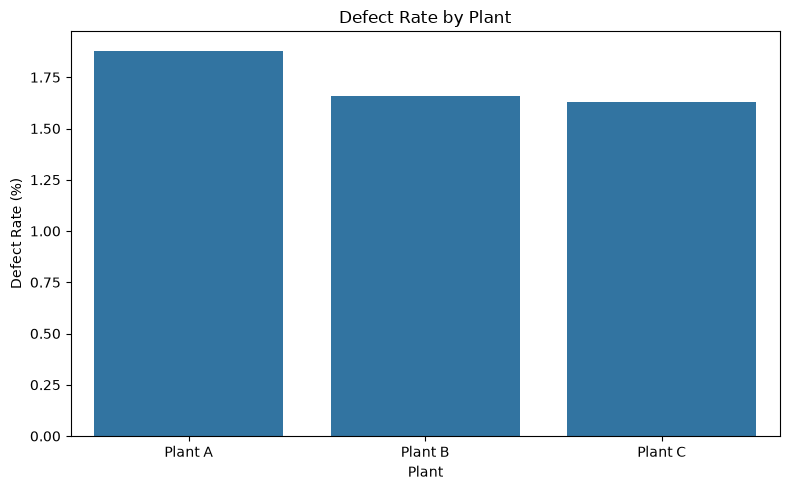

In [124]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=plant_analysis,
    x="Plant",
    y="Defect_Rate"
)

plt.title("Defect Rate by Plant")
plt.xlabel("Plant")
plt.ylabel("Defect Rate (%)")
plt.tight_layout()
plt.savefig("figures/defect_rate_by_plant.png", dpi=300, bbox_inches="tight")
plt.show()

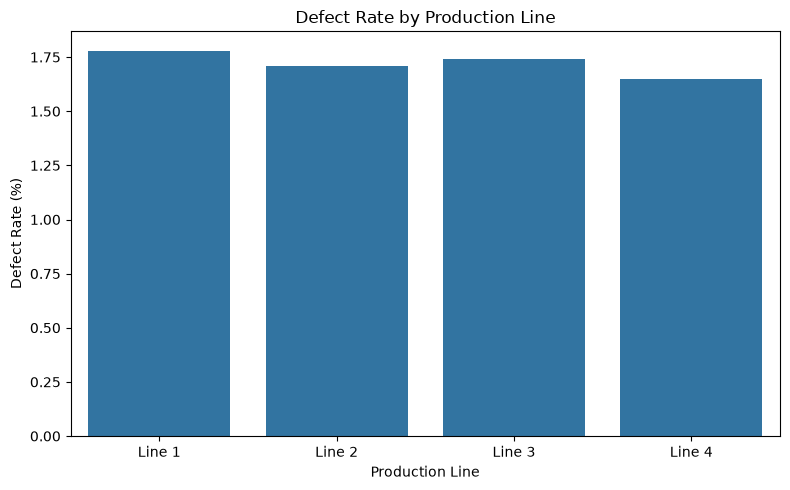

In [125]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=line_analysis,
    x="Production_Line",
    y="Defect_Rate"
)

plt.title("Defect Rate by Production Line")
plt.xlabel("Production Line")
plt.ylabel("Defect Rate (%)")
plt.tight_layout()
plt.savefig("figures/defect_rate_by_line.png", dpi=300, bbox_inches="tight")
plt.show()

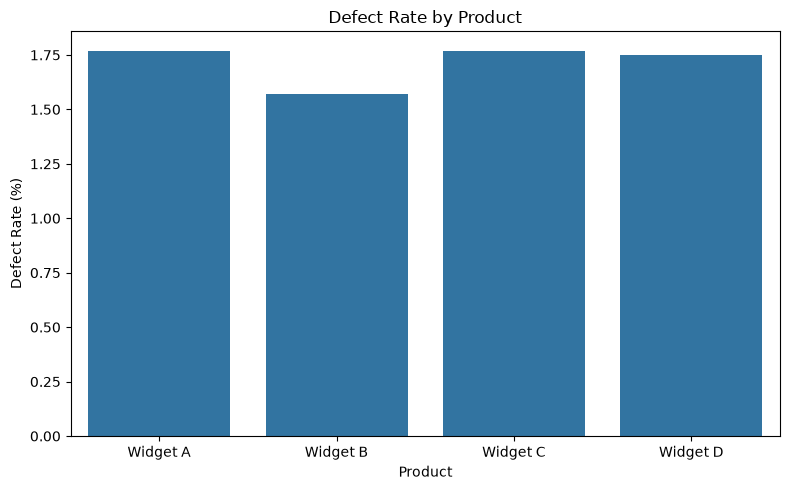

In [126]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=product_analysis,
    x="Product",
    y="Defect_Rate"
)

plt.title("Defect Rate by Product")
plt.xlabel("Product")
plt.ylabel("Defect Rate (%)")
plt.tight_layout()
plt.savefig("figures/defect_rate_by_product.png", dpi=300, bbox_inches="tight")
plt.show()

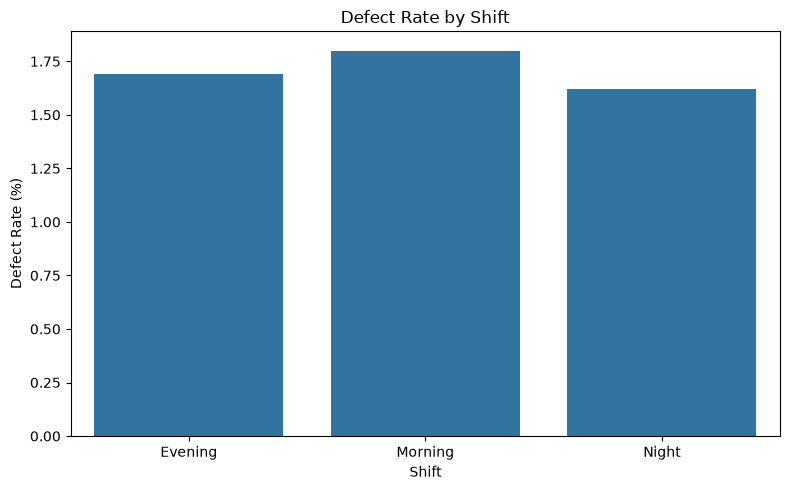

In [127]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=shift_analysis,
    x="Shift",
    y="Defect_Rate"
)

plt.title("Defect Rate by Shift")
plt.xlabel("Shift")
plt.ylabel("Defect Rate (%)")
plt.tight_layout()
plt.savefig("figures/defect_rate_by_shift.png", dpi=300, bbox_inches="tight")
plt.show()

In [128]:
monthly_analysis["Month"] = monthly_analysis["Inspection_Date"].dt.to_timestamp()

monthly_analysis[["Inspection_Date", "Month"]].head()

,Inspection_Date,Month
0,2025-01,2025-01-01
1,2025-02,2025-02-01
2,2025-03,2025-03-01
3,2025-04,2025-04-01
4,2025-05,2025-05-01


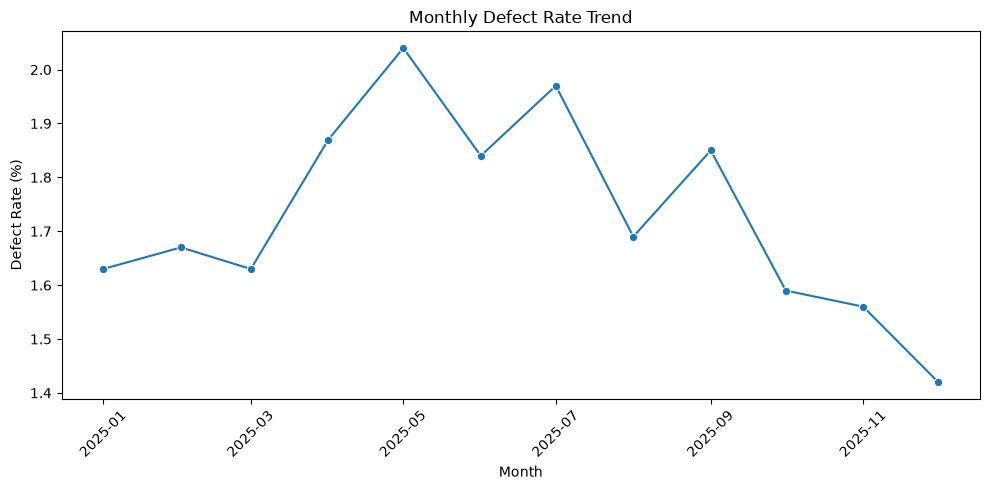

In [129]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_analysis,
    x="Month",
    y="Defect_Rate",
    marker="o"
)

plt.title("Monthly Defect Rate Trend")
plt.xlabel("Month")
plt.ylabel("Defect Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figures/monthly_defect_rate_trend.png", dpi=300, bbox_inches="tight")
plt.show()

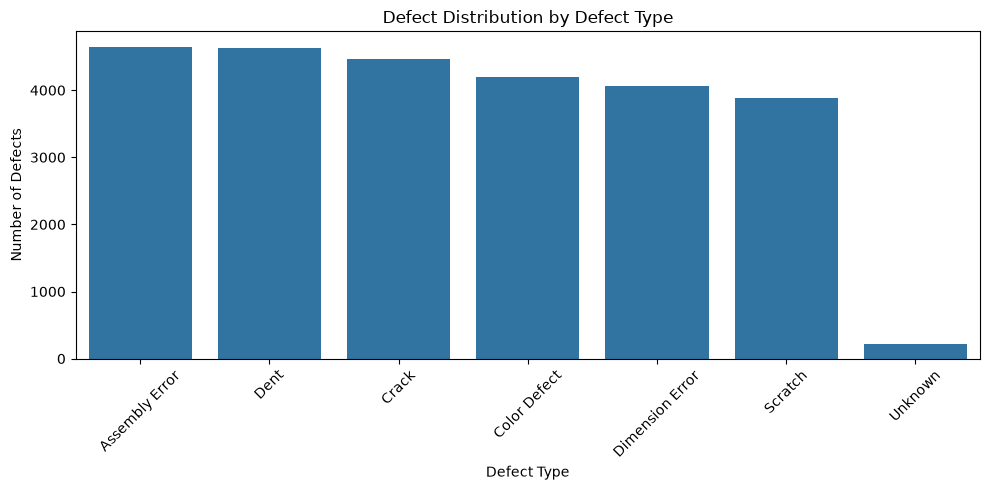

In [130]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=defect_analysis,
    x="Defect_Type",
    y="Defects"
)

plt.title("Defect Distribution by Defect Type")
plt.xlabel("Defect Type")
plt.ylabel("Number of Defects")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figures/defect_distribution_by_type.png", dpi=300, bbox_inches="tight")
plt.show()

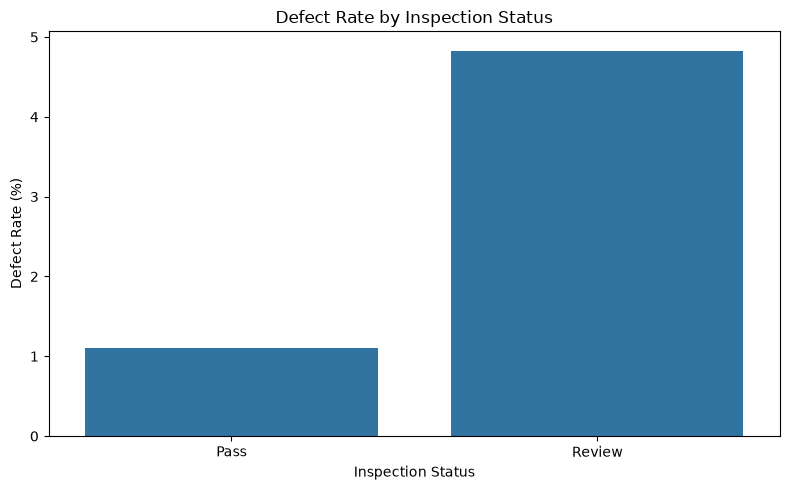

In [131]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=status_analysis,
    x="Inspection_Status",
    y="Defect_Rate"
)

plt.title("Defect Rate by Inspection Status")
plt.xlabel("Inspection Status")
plt.ylabel("Defect Rate (%)")
plt.tight_layout()
plt.savefig("figures/defect_rate_by_inspection_status.png", dpi=300, bbox_inches="tight")
plt.show()

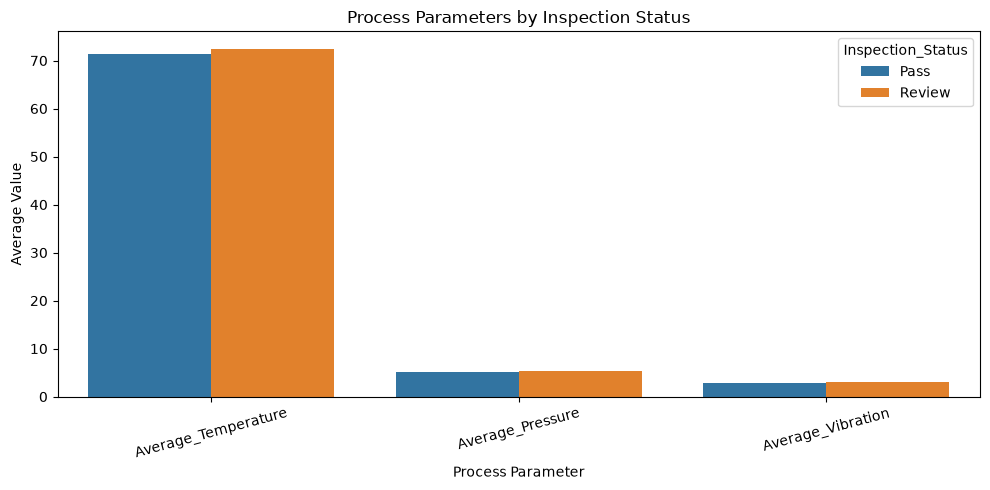

In [132]:
parameter_plot = parameter_analysis.reset_index().melt(
    id_vars="Inspection_Status",
    var_name="Parameter",
    value_name="Average_Value"
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=parameter_plot,
    x="Parameter",
    y="Average_Value",
    hue="Inspection_Status"
)

plt.title("Process Parameters by Inspection Status")
plt.xlabel("Process Parameter")
plt.ylabel("Average Value")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("figures/process_parameters_by_status.png", dpi=300, bbox_inches="tight")
plt.show()

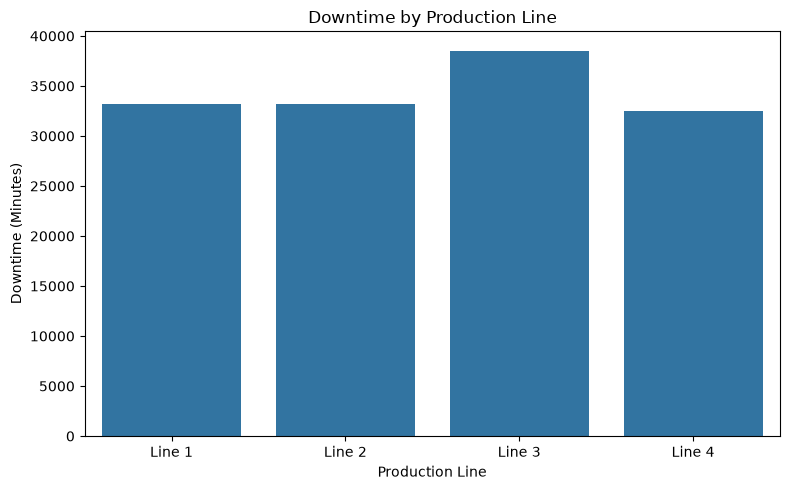

In [133]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=line_analysis,
    x="Production_Line",
    y="Downtime"
)

plt.title("Downtime by Production Line")
plt.xlabel("Production Line")
plt.ylabel("Downtime (Minutes)")
plt.tight_layout()
plt.savefig("figures/downtime_by_line.png", dpi=300, bbox_inches="tight")
plt.show()

In [134]:
correlation_data = df[
    [
        "Production_Qty",
        "Defect_Qty",
        "Downtime_Min",
        "Cycle_Time_Sec",
        "Temperature_C",
        "Pressure_Bar",
        "Vibration_mm_s"
    ]
]

correlation_matrix = correlation_data.corr()

correlation_matrix.round(2)

,Production_Qty,Defect_Qty,Downtime_Min,Cycle_Time_Sec,Temperature_C,Pressure_Bar,Vibration_mm_s
Production_Qty,1.00,0.32,-0.01,0.02,-0.01,-0.00,-0.01
Defect_Qty,0.32,1.00,0.01,0.01,0.05,0.02,0.02
Downtime_Min,-0.01,0.01,1.00,0.01,-0.04,0.02,0.01
Cycle_Time_Sec,0.02,0.01,0.01,1.00,0.01,0.00,0.02
Temperature_C,-0.01,0.05,-0.04,0.01,1.00,-0.02,-0.01
Pressure_Bar,-0.00,0.02,0.02,0.00,-0.02,1.00,-0.02
Vibration_mm_s,-0.01,0.02,0.01,0.02,-0.01,-0.02,1.00


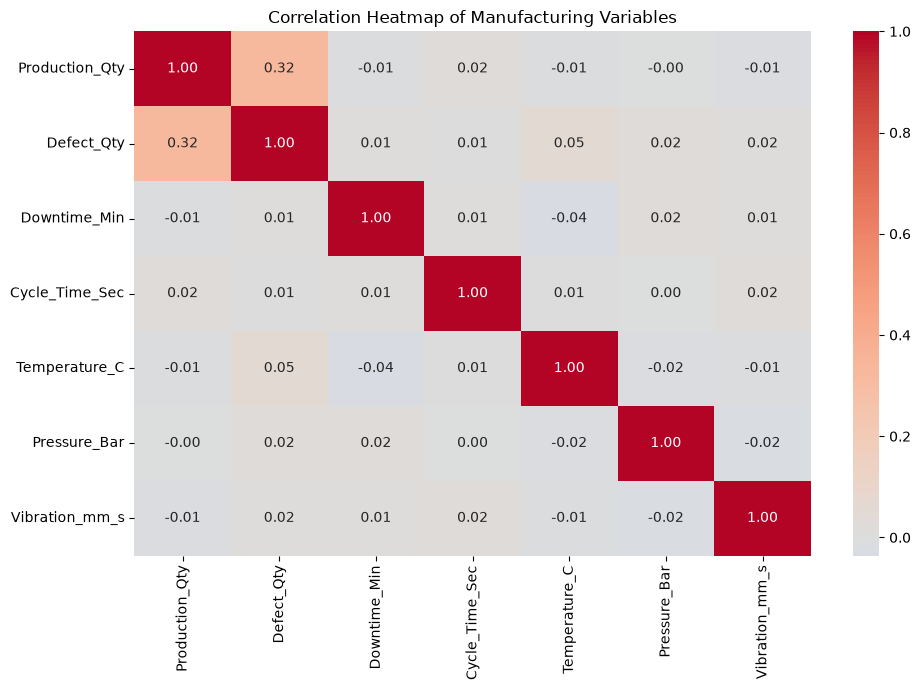

In [135]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Manufacturing Variables")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [136]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Inspections",
        "Total Production",
        "Total Defects",
        "Defect Rate (%)",
        "Quality Rate (%)",
        "Total Downtime (min)",
        "Average Cycle Time (sec)",
        "Average Temperature (°C)",
        "Average Pressure (bar)",
        "Average Vibration (mm/s)"
    ],
    "Value": [
        total_inspections,
        total_production,
        total_defects,
        round(defect_rate, 2),
        round(quality_rate, 2),
        total_downtime,
        round(avg_cycle_time, 2),
        round(avg_temperature, 2),
        round(avg_pressure, 2),
        round(avg_vibration, 2)
    ]
})

kpi_summary

,KPI,Value
0,Total Inspections,1500.00
1,Total Production,1515186.00
2,Total Defects,26093.00
3,Defect Rate (%),1.72
4,Quality Rate (%),98.28
5,Total Downtime (min),137341.00
6,Average Cycle Time (sec),42.01
7,Average Temperature (°C),71.64
8,Average Pressure (bar),5.22
9,Average Vibration (mm/s),2.80


## Business Insights

### Overall Quality Performance
- The dataset contains **1,500 inspections** covering **1,515,186 units of production**.
- A total of **26,093 defects** were recorded, resulting in an overall defect rate of **1.72%** and a quality rate of **98.28%**.
- Total recorded downtime was **137,341 minutes**, indicating a significant operational factor to monitor.

### Plant Performance
- **Plant A** recorded the highest defect rate at **1.88%** and the highest total downtime at **47,099 minutes**.
- Plant B and Plant C recorded defect rates of **1.66%** and **1.63%**, respectively.

### Production Line Performance
- **Line 1** had the highest defect rate among the four production lines at **1.78%**.
- **Line 3** recorded the highest total downtime at **38,532 minutes**.
- Line 4 recorded the lowest defect rate at **1.65%**.

### Product Performance
- **Widget A** and **Widget C** both recorded a defect rate of **1.77%**.
- **Widget B** recorded the lowest product defect rate at **1.57%**.
- Widget C had the highest production volume and highest defect count.

### Shift Performance
- The **Morning shift** recorded the highest defect rate at **1.80%**.
- The **Night shift** recorded the lowest defect rate at **1.62%**.
- The Morning shift also recorded the highest total downtime.

### Defect Patterns
- **Assembly Error** was the largest defect category, accounting for **17.80%** of all defects.
- Dent and Crack followed with **17.74%** and **17.09%**, respectively.

### Inspection Status
- Inspections marked **Review** had a defect rate of **4.83%**, compared with **1.10%** for inspections marked Pass.
- The Review group also showed slightly higher average temperature, pressure, and vibration values.

### Monthly Trend
- The monthly defect rate varied throughout 2025.
- **May 2025** recorded the highest monthly defect rate at approximately **2.04%**.
- The defect rate declined toward the end of the year, reaching approximately **1.42% in December**.

### Process Relationships
- Production Quantity and Defect Quantity showed a correlation of approximately **0.32**, indicating a moderate positive linear relationship.
- Most other process-variable correlations were close to zero, indicating weak linear relationships in this dataset.

### Outlier Monitoring
- **3 temperature**, **2 pressure**, and **3 vibration** observations were flagged for investigation.
- These observations were retained rather than deleted so that potentially important manufacturing conditions are not lost.

## Conclusion

The Manufacturing Quality Analytics project analyzed 1,500 manufacturing inspections using Excel, MySQL, and Python. The analysis measured production volume, defect rates, downtime, process parameters, inspection status, and defect patterns.

The overall defect rate was **1.72%**, with a quality rate of **98.28%**. The analysis identified differences across plants, production lines, products, shifts, defect categories, and inspection statuses. Monthly trends and process-parameter analysis also provided additional quality-monitoring insights.

The findings can support manufacturing teams in identifying areas that require further investigation, monitoring defect patterns, and improving operational quality and efficiency.

The final analysis will be visualized through an interactive **Power BI dashboard** and documented in the project's **GitHub repository**.